**Aim of the project:**

 To Build a sales forecasting model using the appropriate dataset, including data preprocessing, feature engineering, model training, evaluation, and generating future sales predictions, along with visualizations.

Sales forecasting is a critical tool for retail businesses, offering a predictive insight into future sales trends and customer demand. Its importance stems from its ability to directly influence key operational and strategic decisions.

### Importance of Sales Forecasting for Retail Businesses:

1.  **Optimized Resource Allocation:** Accurate forecasts allow businesses to allocate resources more effectively, from staffing levels to marketing spend, ensuring that investments align with anticipated demand.
2.  **Financial Planning:** Sales forecasts are fundamental for financial planning, budgeting, and setting realistic revenue targets. They help in managing cash flow, making investment decisions, and securing financing.
3.  **Strategic Decision Making:** Long-term sales forecasts inform strategic decisions such as store expansion, product development, and market entry strategies.

### How Sales Forecasting Aids in Inventory Management:

Accurate sales forecasts are indispensable for effective inventory management, helping retailers strike a delicate balance between meeting customer demand and minimizing holding costs.

*   **Preventing Stockouts:** By anticipating future sales, businesses can ensure they have sufficient inventory on hand to meet customer demand. This prevents stockouts, which can lead to lost sales, customer dissatisfaction, and damage to brand reputation.
*   **Avoiding Overstocking:** Equally important, sales forecasting helps in avoiding overstocking. Holding excessive inventory ties up capital, incurs storage costs, increases the risk of obsolescence or damage, and can lead to markdowns or liquidation. Accurate forecasts enable businesses to order and store only what is needed, reducing waste and improving profitability.


## Dataset Overview

Load the dataset, display its shape, column names, the first few rows, and data types using pandas. Assume the dataset is named 'sales.csv'.


In [1]:
import pandas as pd

# Load the sales.csv file into a pandas DataFrame
df = pd.read_csv('sales.csv')

# Display the number of rows and columns
print("DataFrame shape:", df.shape)

# Display the names of all columns
print("\nColumn names:", df.columns.tolist())

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
print(df.head())

# Display the data types of each column
print("\nData types of each column:")
df.info()

DataFrame shape: (1867653, 7)

Column names: ['Unnamed: 0', 'date', 'item_id', 'quantity', 'price_base', 'sum_total', 'store_id']

First 5 rows of the DataFrame:
   Unnamed: 0        date       item_id  quantity  price_base  sum_total  \
0           0  2023-08-04  293375605257     1.000       47.86      47.86   
1           1  2023-08-04  a66fdf2c0ae7     3.000       49.60     148.80   
2           2  2023-08-04  daa46ef49b7a     0.822      379.00     311.54   
3           3  2023-08-04  a3b49c1bf758     1.000      129.00     129.00   
4           4  2023-08-04  ab611c5cef62     7.000       79.90     559.30   

   store_id  
0       1.0  
1       1.0  
2       1.0  
3       1.0  
4       1.0  

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1867653 entries, 0 to 1867652
Data columns (total 7 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Unnamed: 0  int64  
 1   date        object 
 2   item_id     object 
 3   quantity    float64
 4   pr

## Data Preprocessing

### Subtask:
Convert the date column to datetime format, check and handle any missing values, and sort the data by date in ascending order.


In [11]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Check missing values
df.isnull().sum()

# Drop rows where store_id is missing
if 'store_id' in df.columns:
    df = df.dropna(subset=['store_id'])
    df['store_id'] = df['store_id'].astype(int)

# Sort by date
df = df.sort_values('date').reset_index(drop=True)

# Preview dataset
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1867652 entries, 0 to 1867651
Data columns (total 7 columns):
 #   Column      Dtype         
---  ------      -----         
 0   Unnamed: 0  int64         
 1   date        datetime64[ns]
 2   item_id     object        
 3   quantity    float64       
 4   price_base  float64       
 5   sum_total   float64       
 6   store_id    int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 99.7+ MB


## Data Aggregation

### Subtask:
Aggregate the dataset to calculate the total daily sales. This will involve summing the 'sum_total' column for each day.


In [4]:
print("Aggregating data to calculate total daily sales...")
daily_sales = df.groupby('date')['sum_total'].sum().reset_index()

print("Daily sales DataFrame created:")
print(daily_sales.head())
print("\nDaily sales info:")
daily_sales.info()

Aggregating data to calculate total daily sales...
Daily sales DataFrame created:
        date   sum_total
0 2023-08-04  4437287.55
1 2023-08-07  3443784.42
2 2023-08-08  3215343.89
3 2023-08-09  3144122.12
4 2023-08-15  3377367.88

Daily sales info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       378 non-null    datetime64[ns]
 1   sum_total  378 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 6.0 KB


## Exploratory Data Analysis (EDA)

### Subtask:
Generate a plot of total daily sales over time to visualize trends and patterns. Ensure the plot has appropriate labels and a legend. I will import the necessary libraries (`matplotlib.pyplot` and `seaborn`) and then generate a line plot using the `daily_sales` DataFrame, ensuring proper labels and a title.


Generating plot for total daily sales over time...


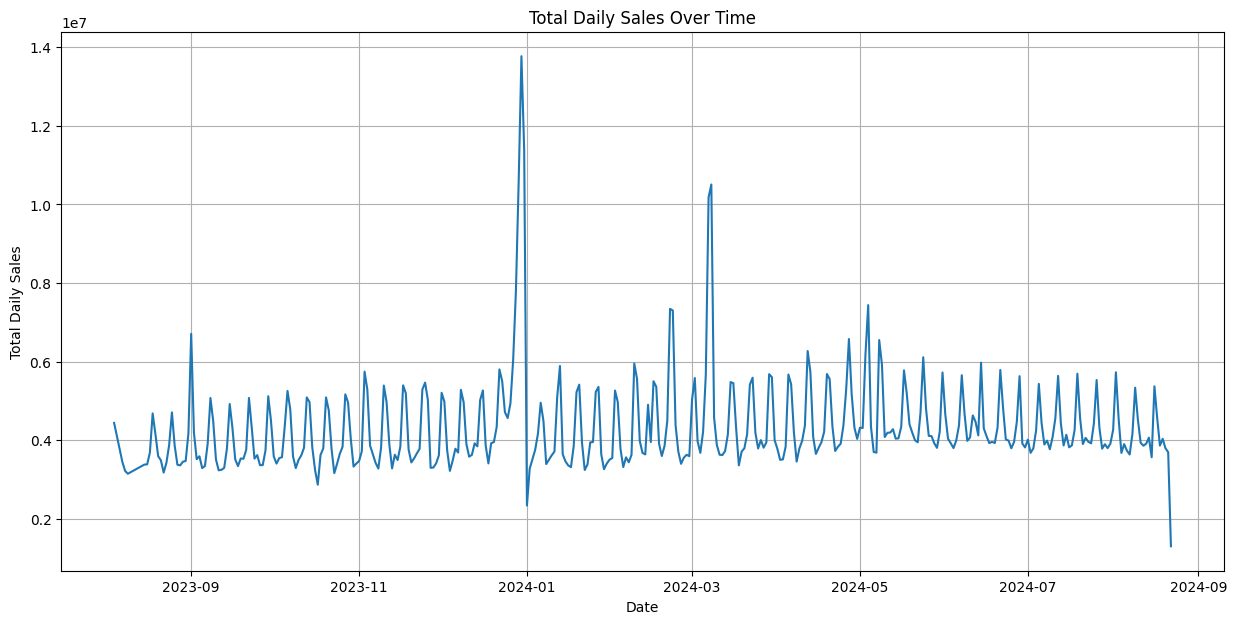

Plot of total daily sales generated.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating plot for total daily sales over time...")

plt.figure(figsize=(15, 7))
sns.lineplot(data=daily_sales, x='date', y='sum_total')
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Daily Sales')
plt.grid(True)
plt.show()

print("Plot of total daily sales generated.")

## Feature Engineering

### Subtask:
Create new features including 'day of week', 'month', 'lag features' (previous day sales), and 'rolling average sales' to enrich the dataset for forecasting.



I will create 'day of week' and 'month' features from the 'date' column, then generate 'sales_lag_1' using `shift(1)` on 'sum_total', and 'rolling_mean_7_days' using `rolling(window=7).mean()` on 'sum_total'.



In [6]:
print("Creating new features: day of week, month, lag features, and rolling average sales...")

# 1. Extract 'day of week' and 'month'
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek
daily_sales['month'] = daily_sales['date'].dt.month

# 2. Create lag features (previous day sales)
daily_sales['sales_lag_1'] = daily_sales['sum_total'].shift(1)

# 3. Create rolling average sales features (7-day rolling average)
daily_sales['rolling_mean_7_days'] = daily_sales['sum_total'].rolling(window=7, min_periods=1).mean()

print("New features added to daily_sales DataFrame:")
print(daily_sales.head(10))
print("\nDataFrame Info after feature engineering:")
daily_sales.info()

Creating new features: day of week, month, lag features, and rolling average sales...
New features added to daily_sales DataFrame:
        date   sum_total  day_of_week  month  sales_lag_1  rolling_mean_7_days
0 2023-08-04  4437287.55            4      8          NaN         4.437288e+06
1 2023-08-07  3443784.42            0      8   4437287.55         3.940536e+06
2 2023-08-08  3215343.89            1      8   3443784.42         3.698805e+06
3 2023-08-09  3144122.12            2      8   3215343.89         3.560134e+06
4 2023-08-15  3377367.88            1      8   3144122.12         3.523581e+06
5 2023-08-16  3382388.07            2      8   3377367.88         3.500049e+06
6 2023-08-17  3683580.84            3      8   3382388.07         3.526268e+06
7 2023-08-18  4680152.72            4      8   3683580.84         3.560963e+06
8 2023-08-19  4158964.77            5      8   4680152.72         3.663131e+06
9 2023-08-20  3592089.16            6      8   4158964.77         3.716952e+06


## Model Building

### Subtask:
Build a sales forecasting model using Linear Regression, leveraging the engineered features. The model will predict 'sum_total'.


**Reasoning**:
I will first remove rows with NaN values from `daily_sales` to ensure clean data for model training. Then, I will define the features (X) and the target variable (y), split the data into training and testing sets chronologically, and finally, instantiate and train a Linear Regression model using the scikit-learn library.



In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

print("1. Removing NaN values from daily_sales...")
daily_sales.dropna(inplace=True)
print("Shape of daily_sales after dropping NaNs:", daily_sales.shape)

print("2. Defining features (X) and target (y)...")
X = daily_sales[['day_of_week', 'month', 'sales_lag_1', 'rolling_mean_7_days']]
y = daily_sales['sum_total']

print("3. Splitting data into training and testing sets chronologically...")
split_index = int(len(daily_sales) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("4. Instantiating and training Linear Regression model...")
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

1. Removing NaN values from daily_sales...
Shape of daily_sales after dropping NaNs: (377, 6)
2. Defining features (X) and target (y)...
3. Splitting data into training and testing sets chronologically...
X_train shape: (301, 4)
X_test shape: (76, 4)
y_train shape: (301,)
y_test shape: (76,)
4. Instantiating and training Linear Regression model...
Linear Regression model trained successfully.


## Model Evaluation

### Subtask:
Evaluate the performance of the chosen forecasting model using relevant metrics such as Mean Absolute Error (MAE) or Root Mean Squared Error (RMSE).


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Making predictions on the test set...")
y_pred = model.predict(X_test)

print("Calculating evaluation metrics...")
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Making predictions on the test set...
Calculating evaluation metrics...

Mean Absolute Error (MAE): 517287.61
Root Mean Squared Error (RMSE): 699616.86


## Sales Forecast

### Subtask:
Generate sales predictions for the next 30 days using the trained forecasting model.


**Reasoning**:
I will generate future dates, extract date-based features, and then use an iterative loop to predict sales for each of the next 30 days. In each iteration, I will use the trained model and update the lag and rolling average features based on the previous day's prediction to ensure accurate sequential forecasting.



In [12]:
# Get last date from historical data
last_date = daily_sales['date'].max()

# Create next 30 days
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)
future_df = pd.DataFrame({'date': future_dates})

# Extract date features
future_df['day_of_week'] = future_df['date'].dt.dayofweek
future_df['month'] = future_df['date'].dt.month

future_predictions = []

# Initialize lag and rolling values
lag_1 = daily_sales['sum_total'].iloc[-1]
rolling_values = daily_sales['sum_total'].iloc[-6:].tolist()

for i in range(len(future_df)):

    rolling_mean = np.mean(rolling_values + [lag_1])

    input_features = pd.DataFrame(
        [[future_df.loc[i,'day_of_week'], future_df.loc[i,'month'], lag_1, rolling_mean]],
        columns=X_train.columns
    )

    pred = model.predict(input_features)[0]
    future_predictions.append(pred)

    lag_1 = pred
    rolling_values.pop(0)
    rolling_values.append(pred)

future_df['predicted_sum_total'] = future_predictions

future_df.head()

,date,day_of_week,month,predicted_sum_total
0,2024-08-23,4,8,2.883338e+06
1,2024-08-24,5,8,3.594493e+06
2,2024-08-25,6,8,4.025819e+06
3,2024-08-26,0,8,3.361857e+06
4,2024-08-27,1,8,3.185646e+06


## Visualization of Forecast

### Subtask:
Create a plot visualizing the historical sales data alongside the predicted future sales for the next 30 days. Ensure clear labels and a legend are included.


Generating plot for historical and forecasted daily sales...


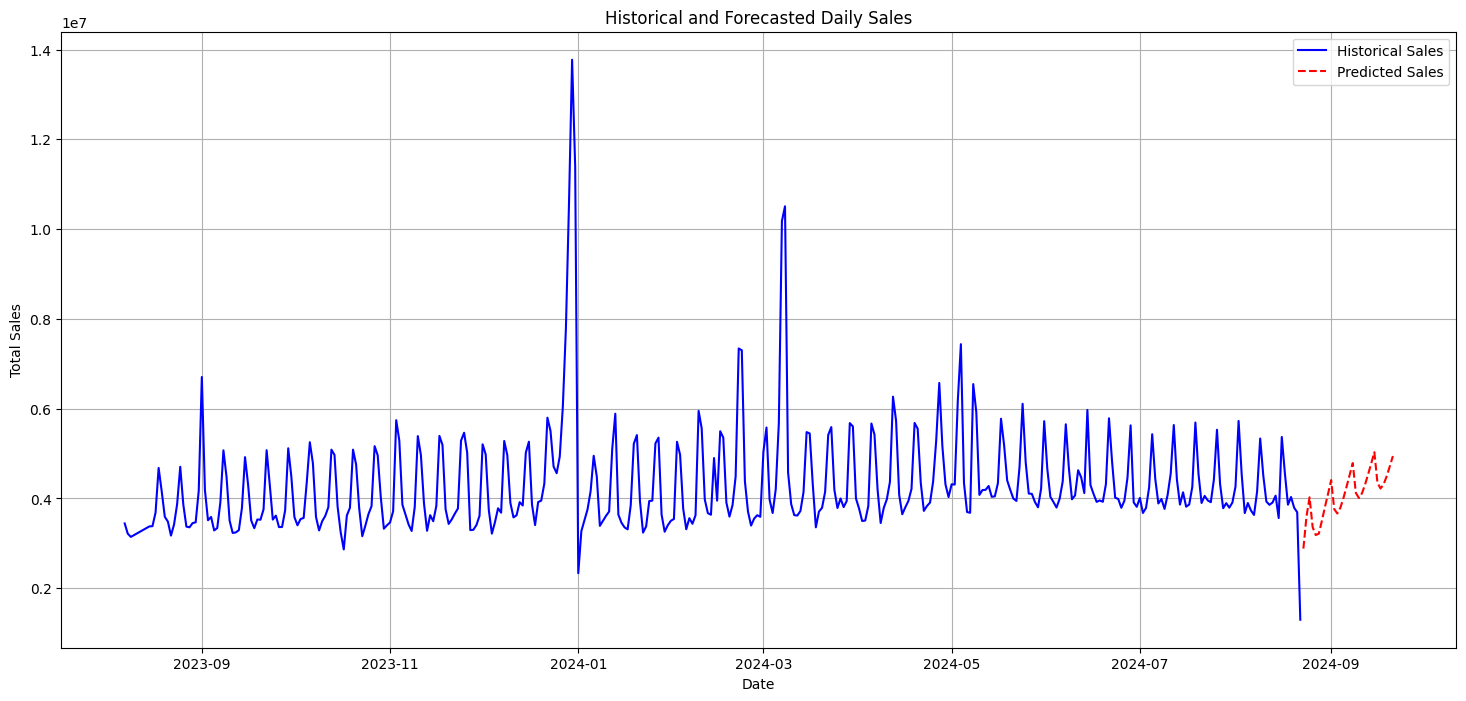

Plot of historical and forecasted daily sales generated.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating plot for historical and forecasted daily sales...")

plt.figure(figsize=(18, 8))
sns.lineplot(x='date', y='sum_total', data=daily_sales, label='Historical Sales', color='blue')
sns.lineplot(x='date', y='predicted_sum_total', data=future_predictions_df, label='Predicted Sales', color='red', linestyle='--')

plt.title('Historical and Forecasted Daily Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

print("Plot of historical and forecasted daily sales generated.")

## Conclusion

### Sales Forecasting Model Insights and Retail Implications

The sales forecasting project utilized historical sales data, enriched with engineered features like day of week, month, lag sales, and rolling averages, to build a Linear Regression model. This model was then used to predict future daily sales.

### Model Performance:

*   **Mean Absolute Error (MAE):** 517,287.61
*   **Root Mean Squared Error (RMSE):** 699,616.86



### Visualization of Forecast:

The "Historical and Forecasted Daily Sales" plot reveals several key insights:

1.  **Historical Trends:** The historical data shows noticeable fluctuations in daily sales, with some periods exhibiting higher sales volumes than others. There appears to be some weekly or monthly seasonality, as indicated by peaks and troughs.
2.  **Forecasted Trends:** The 30-day forecast projects continued fluctuations, aligning with the historical patterns. It doesn't show extreme deviations, indicating a relatively stable but dynamic sales pattern for the upcoming period.

### Implications for Retail Stores:

The insights from this sales forecasting model have significant practical implications for retail businesses:

*   **Inventory Management:** By anticipating future sales, retailers can optimize inventory levels. The forecast helps prevent stockouts during periods of high demand and avoids overstocking, which reduces holding costs and minimizes waste. More accurate predictions mean a leaner, more efficient supply chain.

*   **Marketing and Promotions:** Retailers can strategically plan marketing campaigns and promotions based on forecasted sales. For instance, if a dip in sales is predicted, targeted promotions could be launched to stimulate demand. Conversely, during periods of high forecasted sales, resources could be shifted to maximize conversions rather than aggressive outreach.
*   **Financial Planning and Budgeting:** Accurate sales forecasts are crucial for financial planning, budgeting, and setting realistic revenue targets. They enable better cash flow management, informed investment decisions, and more precise allocation of financial resources across different business functions.


In conclusion, this sales forecasting model provides valuable predictive insights that empower retail businesses to make data-driven decisions across various operational and strategic areas, ultimately contributing to improved efficiency, profitability, and customer satisfaction.